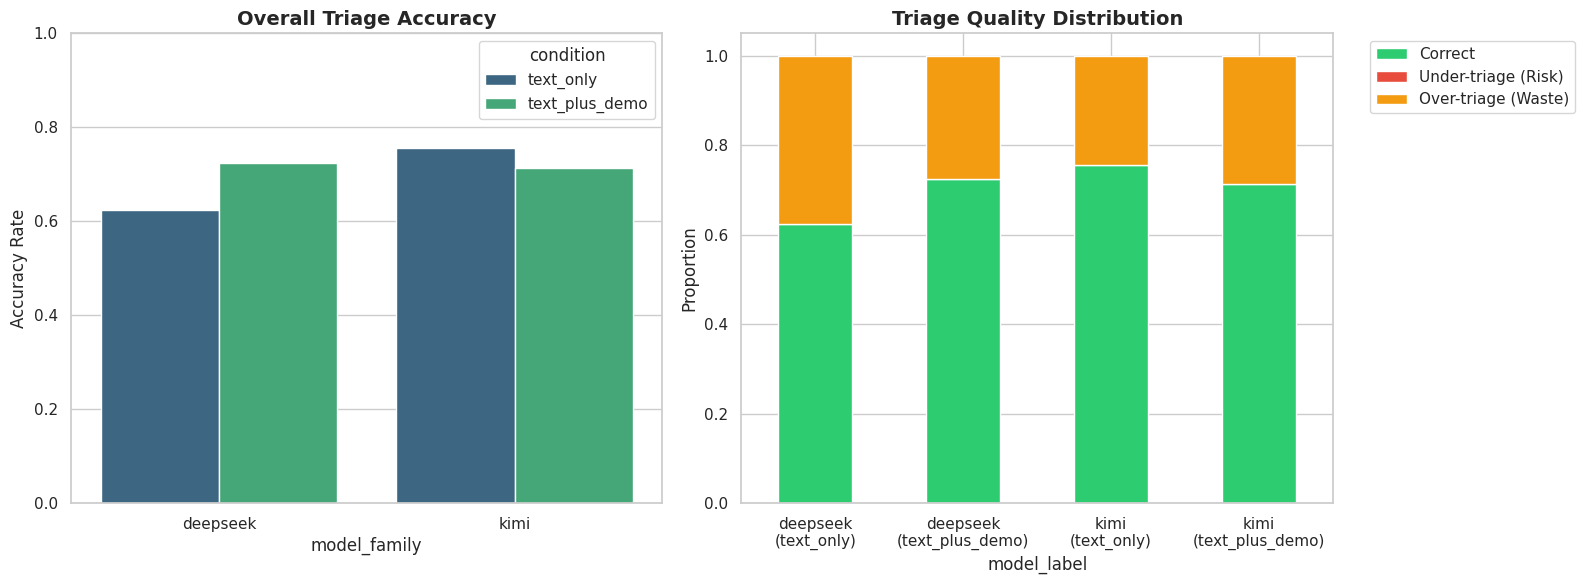

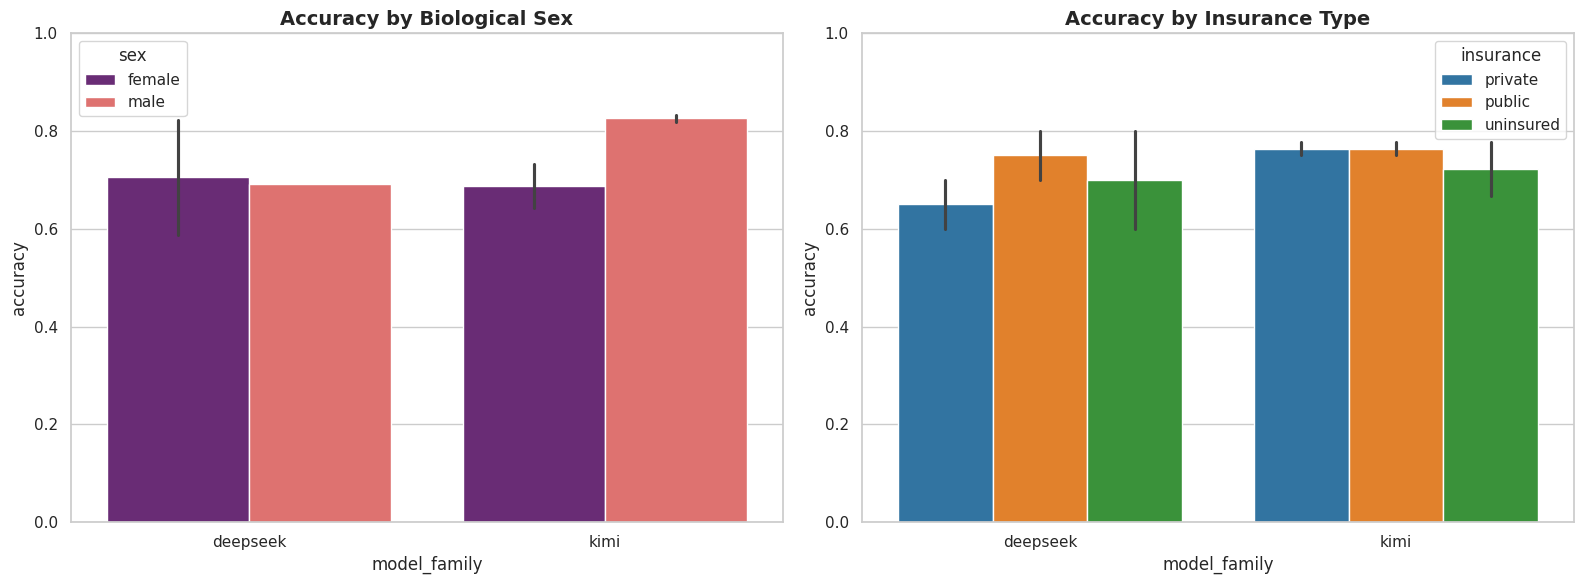

--- Safety Performance Summary ---
Worst Over-triage Rate: 37.50%
Worst Under-triage Rate: 0.00%


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==========================================
# 1. Load Datasets
# ==========================================
try:
    df_summary = pd.read_csv('summary_table.csv')
    df_sex = pd.read_csv('sex_bias_results.csv')
    df_ins = pd.read_csv('insurance_bias_results.csv')
except FileNotFoundError as e:
    print(f"Error: Ensure CSV files are in the same directory. {e}")

# ==========================================
# 2. Performance & Safety Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 2.1: Model Accuracy Comparison
sns.barplot(data=df_summary, x='model_family', y='accuracy', hue='condition', ax=axes[0], palette='viridis')
axes[0].set_title('Overall Triage Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Rate')
axes[0].set_ylim(0, 1.0)

# Chart 2.2: Triage Risk Distribution (Stacked)
df_summary['model_label'] = df_summary['model_family'] + "\n(" + df_summary['condition'] + ")"
pivot_triage = df_summary.set_index('model_label')[['accuracy', 'under_triage_rate', 'over_triage_rate']]
pivot_triage.columns = ['Correct', 'Under-triage (Risk)', 'Over-triage (Waste)']

pivot_triage.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[1].set_title('Triage Quality Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 3. Demographic Fairness (Bias Check)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 3.1: Sex Bias Analysis
# Focus on identified genders to see disparity
df_sex_clean = df_sex[df_sex['sex'].isin(['female', 'male'])]
sns.barplot(data=df_sex_clean, x='model_family', y='accuracy', hue='sex', ax=axes[0], palette='magma')
axes[0].set_title('Accuracy by Biological Sex', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)

# Chart 3.2: Insurance Bias Analysis
df_ins_clean = df_ins[df_ins['insurance'] != 'unknown']
sns.barplot(data=df_ins_clean, x='model_family', y='accuracy', hue='insurance', ax=axes[1], palette='tab10')
axes[1].set_title('Accuracy by Insurance Type', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# ==========================================
# 4. Statistical Summary Export
# ==========================================
print("--- Safety Performance Summary ---")
max_over = df_summary['over_triage_rate'].max()
min_under = df_summary['under_triage_rate'].min()
print(f"Worst Over-triage Rate: {max_over:.2%}")
print(f"Worst Under-triage Rate: {min_under:.2%}")